In [1]:
import sys
sys.path.append("..")  # Adds the parent directory to the path
from utilities.correlations import *
from utilities.explanation import *
from utilities.for_ploting import *
from utilities.imputation import *
from utilities.modelling import *
from utilities.preprocessing import *
from utilities.feature_engineering import *
from utilities.cleaning import *
import pandas as pd

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
train_df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [4]:
train_df.nunique()

id                 165034
CustomerId          23221
Surname              2797
CreditScore           457
Geography               3
Gender                  2
Age                    71
Tenure                 11
Balance             30075
NumOfProducts           4
HasCrCard               2
IsActiveMember          2
EstimatedSalary     55298
Exited                  2
dtype: int64

In [5]:
target = 'Exited'

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [7]:
train_df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


## EDA

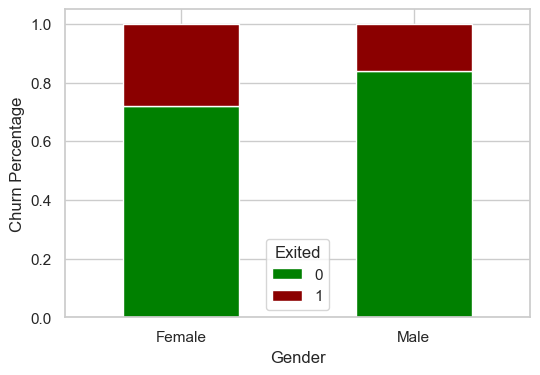

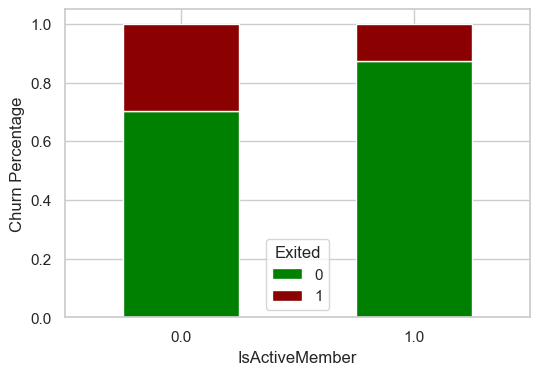

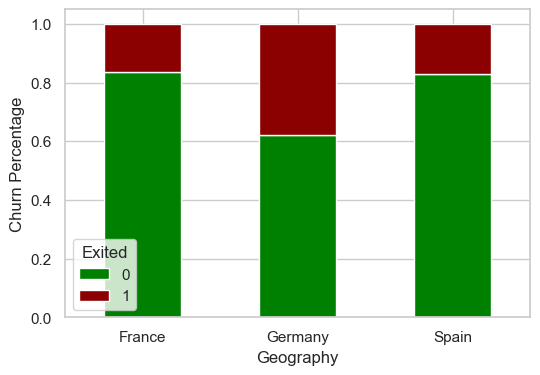

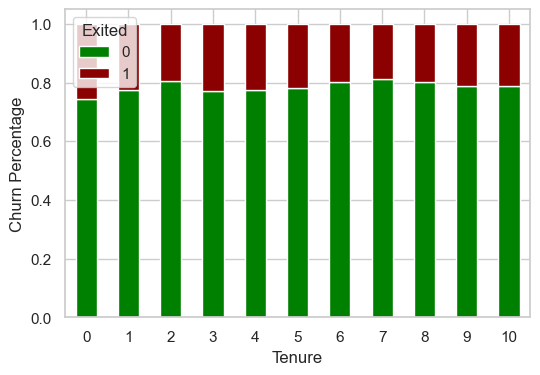

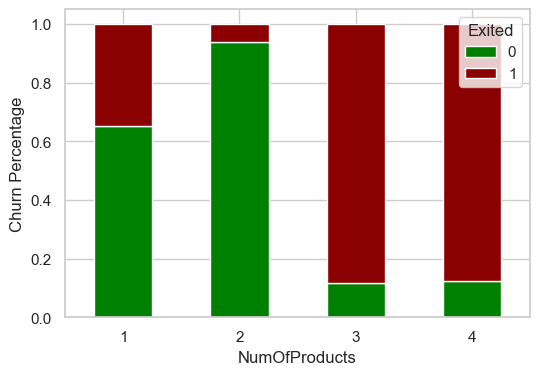

In [8]:
stacked_plot(train_df, 'Gender', target)
stacked_plot(train_df, 'IsActiveMember', target)
stacked_plot(train_df, 'Geography', target)
stacked_plot(train_df, 'Tenure', target)
stacked_plot(train_df, 'NumOfProducts', target)

In [9]:
test_df[target] = np.array([0] * len(test_df))

In [10]:
all_samples = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [11]:
features = all_samples.columns.tolist()
features = [col for col in features if col not in ['id','CustomerId', 'Surname',target]]

In [12]:
all_samples = cluster_and_assign_group_prediction(all_samples.drop(['Surname'],axis=1), train_df.shape[0],features, 10, target)

In [13]:
train_x = all_samples.iloc[:train_df.shape[0],:].drop(['id','CustomerId', 'Exited'],axis=1)
test_x = all_samples.iloc[train_df.shape[0]:,:].drop(['id','CustomerId', 'Exited'],axis=1)
train_y = all_samples.iloc[:train_df.shape[0],:]['Exited']

In [14]:
cat_cols = train_x.select_dtypes(exclude='number')
for col in cat_cols:
    train_x[col] = train_x[col].astype('category')
    test_x[col] = test_x[col].astype('category')

In [15]:
params = {
    'n_estimators':1000,
    'learning_rate':0.1
}

Class unbalanced: True
[LightGBM] [Info] Number of positive: 31429, number of negative: 117101
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.254277
[LightGBM] [Debug] init for col-wise cost 0.000010 seconds, init for row-wise cost 0.010761 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 882
[LightGBM] [Info] Number of data points in the train set: 148530, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.211600 -> initscore=-1.315306
[LightGBM] [Info] Start training from score -1.315306
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 8
[1]	valid_0's auc: 0.875396	valid_0's binary_logloss: 0.476561
Training until validation scores don't improve for 100 rounds
[Ligh

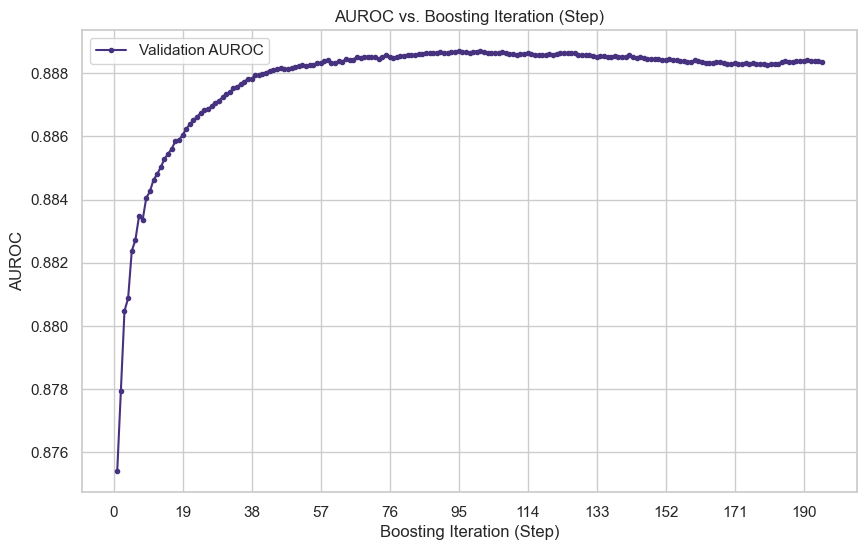


Best Iteration (based on validation AUROC): 95
Best Validation AUROC: 0.8887


In [16]:
model = training_binary_classification_with_lgbm(train_x,train_y,params=params,split=0.1)

C:\Users\qli97\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


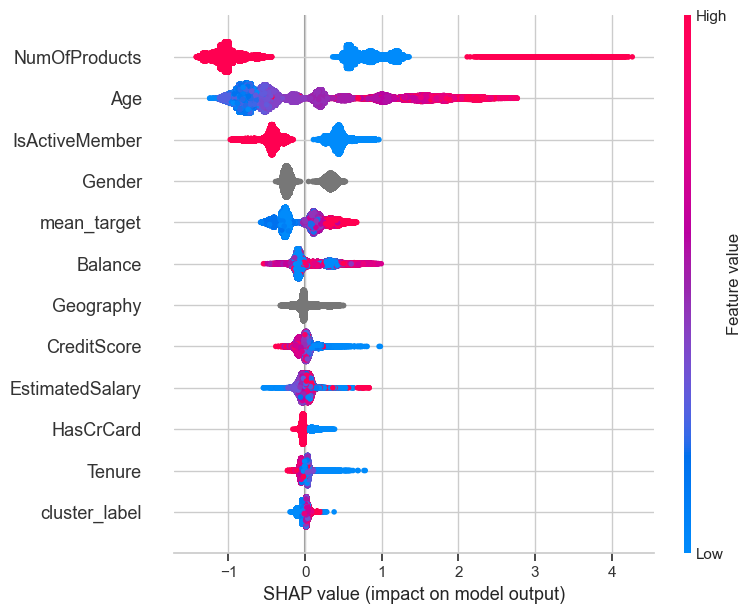

<Figure size 1400x800 with 0 Axes>

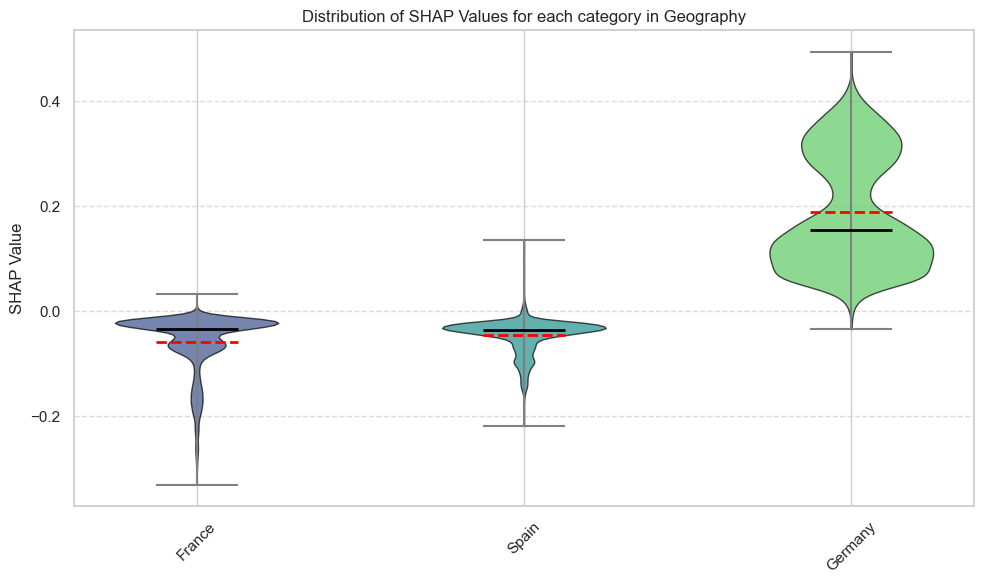

<Figure size 1400x800 with 0 Axes>

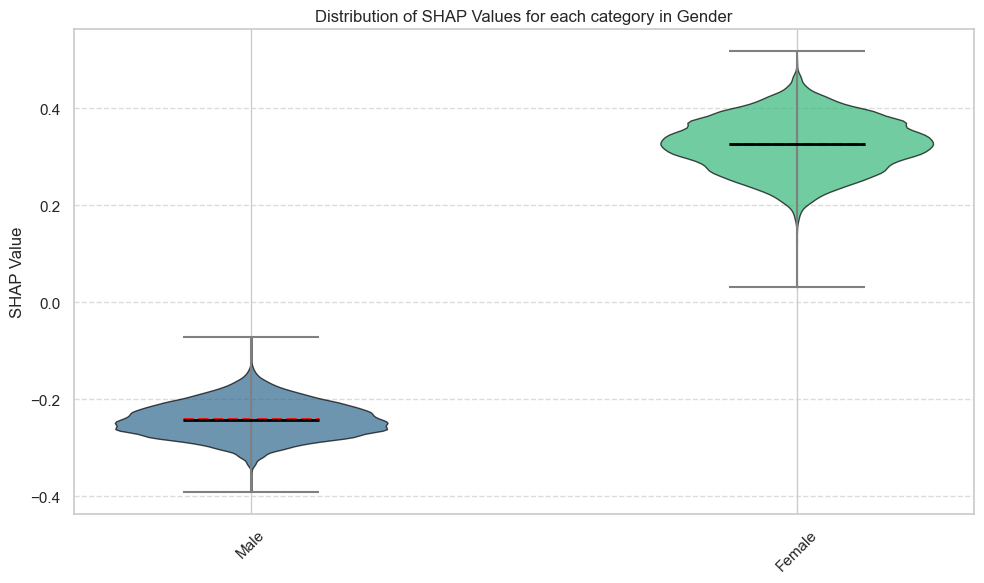

In [17]:
features = train_x.columns.tolist()
shap_explain_model_on_batch(model, train_x, features)

In [18]:
predictions = model.predict_proba(test_x)[:, 1]
submission_df = pd.DataFrame({"id": test_df["id"], "Exited": predictions})
submission_df.to_csv("submission.csv", index=False)


## Private Score: 0.88863, Public Score: 0.88436